##Final Project: Travel Review Analysis
##OPAN 6603 - Customer Segmentation using PCA and Clustering
##Wagma Saboor

In [ ]:
#STEP 0:Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import umap.umap_ as umap

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [ ]:
from google.colab import files
uploaded = files.upload()



Saving Travel_Review.xlsx to Travel_Review (1).xlsx


In [ ]:
#Step 1: Load Data & Train-Test Split

df_raw = pd.read_excel("Travel_Review.xlsx")
df = df_raw.copy()

print(f"Total dataset: {df.shape}")
df.head()

# Separate features and IDs
feature_cols = df.columns.drop('UserID')
X_raw_full = df[feature_cols].copy()

# CRITICAL: Split BEFORE any analysis
X_train_raw, X_test_raw = train_test_split(
    X_raw_full,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True
)

print(f"\nTrain set: {X_train_raw.shape[0]:,} users ({X_train_raw.shape[0]/len(X_raw_full)*100:.1f}%)")
print(f"Test set:  {X_test_raw.shape[0]:,} users ({X_test_raw.shape[0]/len(X_raw_full)*100:.1f}%)")
print("\n✓ All subsequent analysis will use TRAINING DATA ONLY")
print("✓ Test set is held out for final validation")

# Work with training data for all EDA and modeling
X_raw = X_train_raw.copy()



Total dataset: (5455, 25)

Train set: 4,364 users (80.0%)
Test set:  1,091 users (20.0%)

✓ All subsequent analysis will use TRAINING DATA ONLY
✓ Test set is held out for final validation


In [ ]:
# STEP 2 — MISSING VALUES + ZERO TREATMENT(TRAINING DATA ONLY)

# --------------------------------------------------
# CRITICAL MODELING DECISION
# --------------------------------------------------
# In this dataset, 0 does NOT represent a rating.
# It represents a non-visit / no review.
# Therefore we treat 0 as structural missing data.

# Inspect missing
missing_counts = X_raw.isna().sum()
print("\nMissing values before treatment:")
print(missing_counts[missing_counts > 0])

# Inspect zeros (behavioral non-visits)
zero_counts = (X_raw == 0).sum()
zero_pct = (zero_counts / len(X_raw) * 100).round(2)

zero_summary = pd.DataFrame({
    "Zero Count": zero_counts,
    "Zero %": zero_pct
}).sort_values("Zero %", ascending=False)

print("\nZero values per feature (non-visits) - TRAINING DATA:")
display(zero_summary)

# Treat 0 as structural missing data
X_clean = X_raw.replace(0, np.nan)

# Impute using TRAINING median only
train_medians = X_clean.median()
X_clean = X_clean.fillna(train_medians)

# Final verification
assert X_clean.isna().sum().sum() == 0, "Still missing values exist!"

print("\n✓ Zeros treated as non-visits and imputed using TRAINING medians")

X_behavior = X_clean.copy()

print("✓ Clean training dataset ready for analysis")



Missing values before treatment:
Gardens    1
dtype: int64

Zero values per feature (non-visits) - TRAINING DATA:


,Zero Count,Zero %
Bakeries,830,19.02
Gyms,810,18.56
BeautySpas,717,16.43
Cafes,487,11.16
Swimming Pools,382,8.75
ViewPoints,277,6.35
Monuments,239,5.48
Gardens,184,4.22
Churches,157,3.60
DanceClubs,90,2.06



✓ Zeros treated as non-visits and imputed using TRAINING medians
✓ Clean training dataset ready for analysis


In [ ]:
# STEP 3: DESCRIPTIVE STATISTICS (TRAINING DATA)

desc = X_behavior.describe().T
desc['cv'] = (desc['std'] / desc['mean']).round(2)

print("\nDescriptive statistics (TRAINING DATA - original 1–5 scale):")
display(desc[['mean','std','min','50%','max','cv']].sort_values('mean', ascending=False))



Descriptive statistics (TRAINING DATA - original 1–5 scale):


,mean,std,min,50%,max,cv
Malls,3.357908,1.412523,1.12,3.230,5.0,0.42
Restaurants,3.130085,1.356403,0.84,2.810,5.0,0.43
Theatres,2.952271,1.335737,1.12,2.660,5.0,0.45
Museums,2.890623,1.278445,1.11,2.685,5.0,0.44
Pubs_Bars,2.848932,1.308197,0.81,2.690,5.0,0.46
Parks,2.785353,1.305052,0.83,2.450,5.0,0.47
LocalServices,2.559883,1.386555,0.78,2.010,5.0,0.54
Zoo,2.547649,1.114696,0.86,2.170,5.0,0.44
Beaches,2.483261,1.243211,0.52,2.050,5.0,0.50
Resorts,2.354748,1.396033,0.50,1.960,5.0,0.59


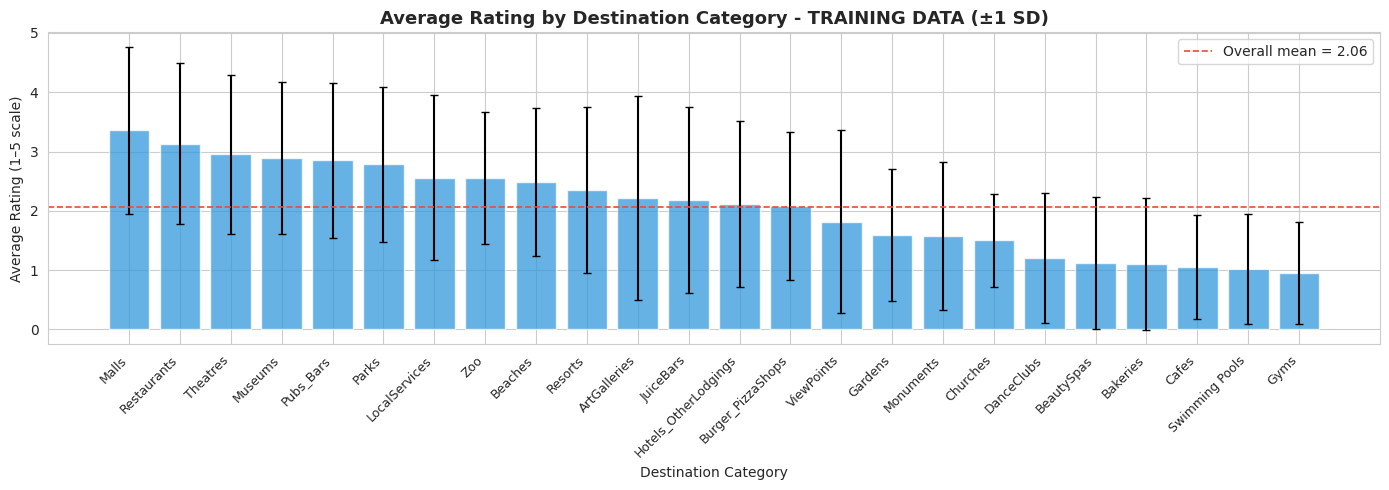

In [ ]:

# EDA Plot 1: Mean ratings with standard deviation bars
means = X_behavior.mean().sort_values(ascending=False)
stds  = X_behavior.std()

fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    range(len(means)),
    means.values,
    yerr=stds[means.index].values,
    capsize=3,
    color='#3498DB',
    alpha=0.75,
    edgecolor='white'
)

ax.set_xticks(range(len(means)))
ax.set_xticklabels(means.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Average Rating (1–5 scale)')
ax.set_xlabel('Destination Category')
ax.set_title('Average Rating by Destination Category - TRAINING DATA (±1 SD)',
             fontsize=13, fontweight='bold')

overall_mean = means.mean()
ax.axhline(overall_mean, color='#E74C3C', linestyle='--',
           linewidth=1.2, label=f'Overall mean = {overall_mean:.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('eda_mean_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

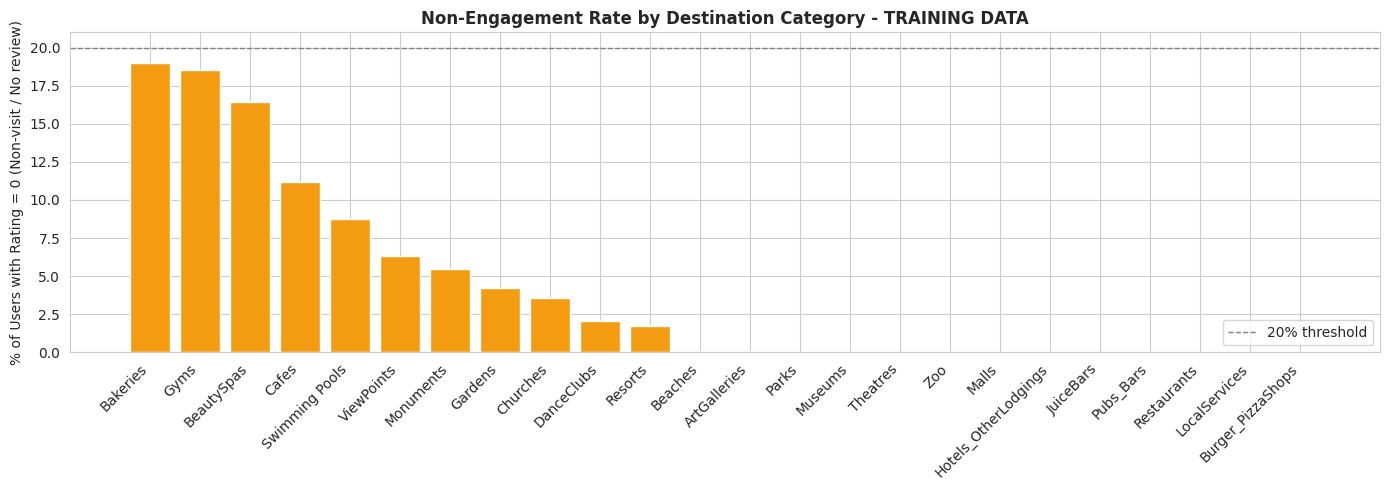

In [ ]:
# EDA Plot 2 — Non-engagement rate
zero_pct_original = (X_raw == 0).mean() * 100
zero_pct_sorted = zero_pct_original.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(range(len(zero_pct_sorted)), zero_pct_sorted.values,
       color='#F39C12', edgecolor='white')

ax.set_xticks(range(len(zero_pct_sorted)))
ax.set_xticklabels(zero_pct_sorted.index, rotation=45, ha='right')
ax.set_ylabel('% of Users with Rating = 0 (Non-visit / No review)')
ax.set_title('Non-Engagement Rate by Destination Category - TRAINING DATA', fontweight='bold')
ax.axhline(20, color='gray', linestyle='--', linewidth=1, label='20% threshold')
ax.legend()

plt.tight_layout()
plt.savefig('eda_zero_pct.png', dpi=150, bbox_inches='tight')
plt.show()




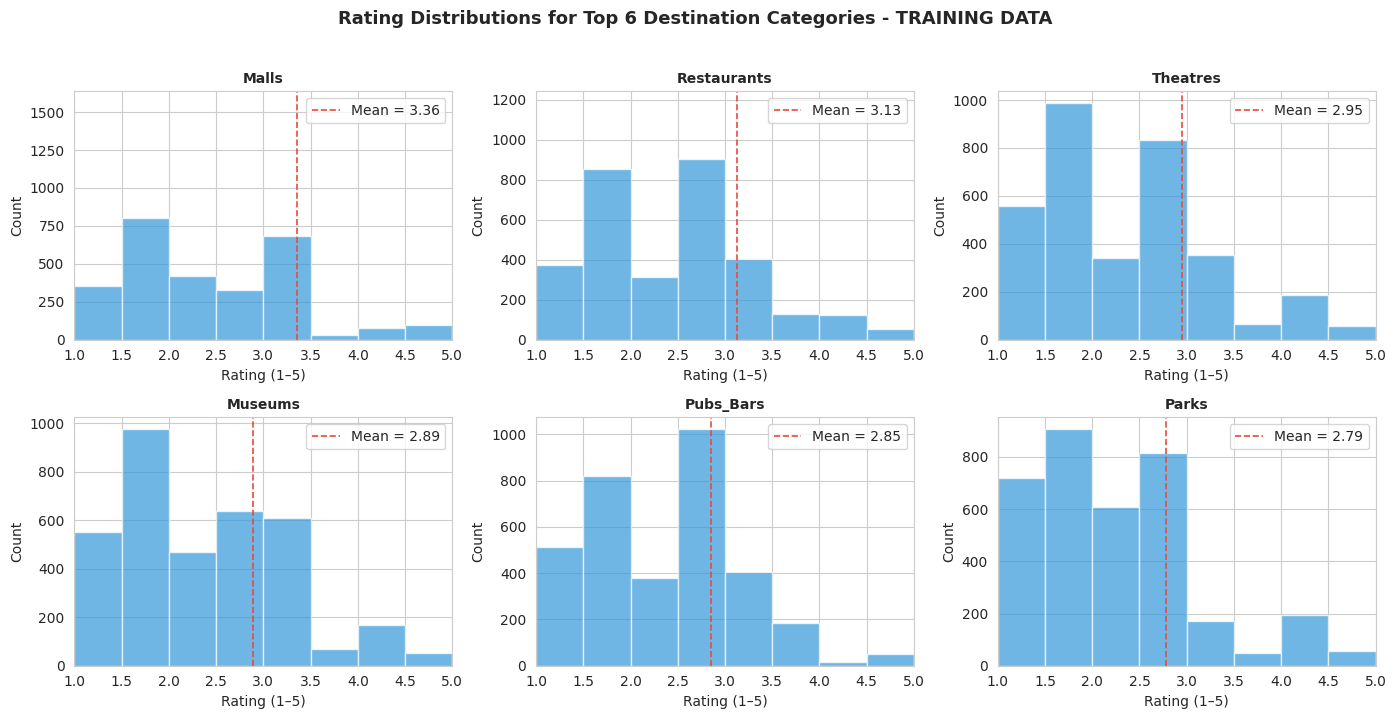

In [ ]:
# EDA Plot 3: Distribution of ratings for top 6 features
top6 = means.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(axes.flatten(), top6):
    ratings = X_behavior[col]

    ax.hist(ratings, bins=np.arange(0.5, 5.6, 0.5),
            color='#3498DB', alpha=0.7, edgecolor='white')

    ax.axvline(ratings.mean(), color='#E74C3C', linestyle='--',
               linewidth=1.2, label=f"Mean = {ratings.mean():.2f}")

    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Rating (1–5)')
    ax.set_ylabel('Count')
    ax.set_xlim(1,5)
    ax.legend()

plt.suptitle('Rating Distributions for Top 6 Destination Categories - TRAINING DATA',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


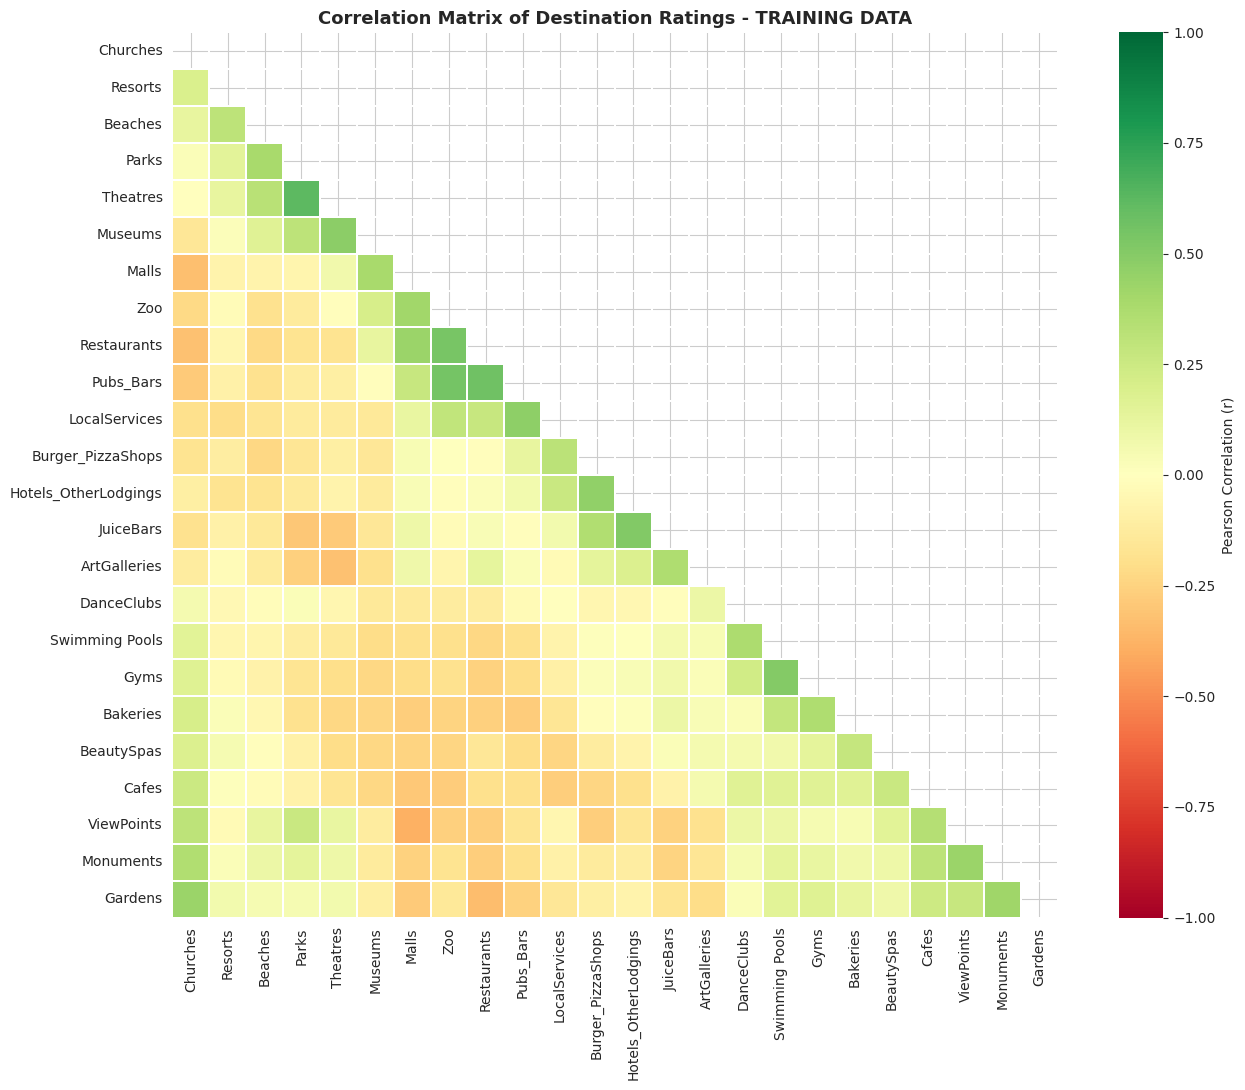

In [ ]:
# EDA Plot 4: Correlation Heatmap
corr = X_behavior.corr()

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, square=True,
            cbar_kws={'label': 'Pearson Correlation (r)'}, ax=ax)

ax.set_title('Correlation Matrix of Destination Ratings - TRAINING DATA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# THEMATIC ENGAGEMENT SCORES (TRAINING DATA)
# ═══════════════════════════════════════════════════════════════

engagement_df = pd.DataFrame(index=X_raw.index)

culture      = ['Churches','Museums','Theatres','ArtGalleries','Monuments']
nature_relax = ['Parks','Gardens','ViewPoints','Beaches','Resorts','Swimming Pools']
food_drink   = ['Restaurants','Pubs_Bars','Cafes','Bakeries','JuiceBars','Burger_PizzaShops']
nightlife    = ['DanceClubs','Malls']
wellness     = ['Gyms','BeautySpas','Hotels_OtherLodgings']
services     = ['LocalServices','Zoo']

engagement_df['Culture_Score']     = X_raw[culture].mean(axis=1)
engagement_df['NatureRelax_Score'] = X_raw[nature_relax].mean(axis=1)
engagement_df['FoodDrink_Score']   = X_raw[food_drink].mean(axis=1)
engagement_df['Nightlife_Score']   = X_raw[nightlife].mean(axis=1)
engagement_df['Wellness_Score']    = X_raw[wellness].mean(axis=1)
engagement_df['Services_Score']    = X_raw[services].mean(axis=1)

print("Thematic Score Summary - TRAINING DATA:")
display(engagement_df.describe().round(3))


Thematic Score Summary - TRAINING DATA:


,Culture_Score,NatureRelax_Score,FoodDrink_Score,Nightlife_Score,Wellness_Score,Services_Score
count,4364.000,4364.000,4364.000,4364.000,4364.000,4364.000
mean,2.205,1.971,2.029,2.273,1.312,2.554
std,0.564,0.684,0.548,0.834,0.721,1.010
min,0.726,0.373,0.722,0.915,0.277,0.830
25%,1.820,1.395,1.650,1.610,0.787,1.710
50%,2.205,1.966,2.035,2.135,1.047,2.320
75%,2.610,2.477,2.435,2.845,1.964,3.340
max,4.028,4.303,3.873,5.000,5.000,5.000


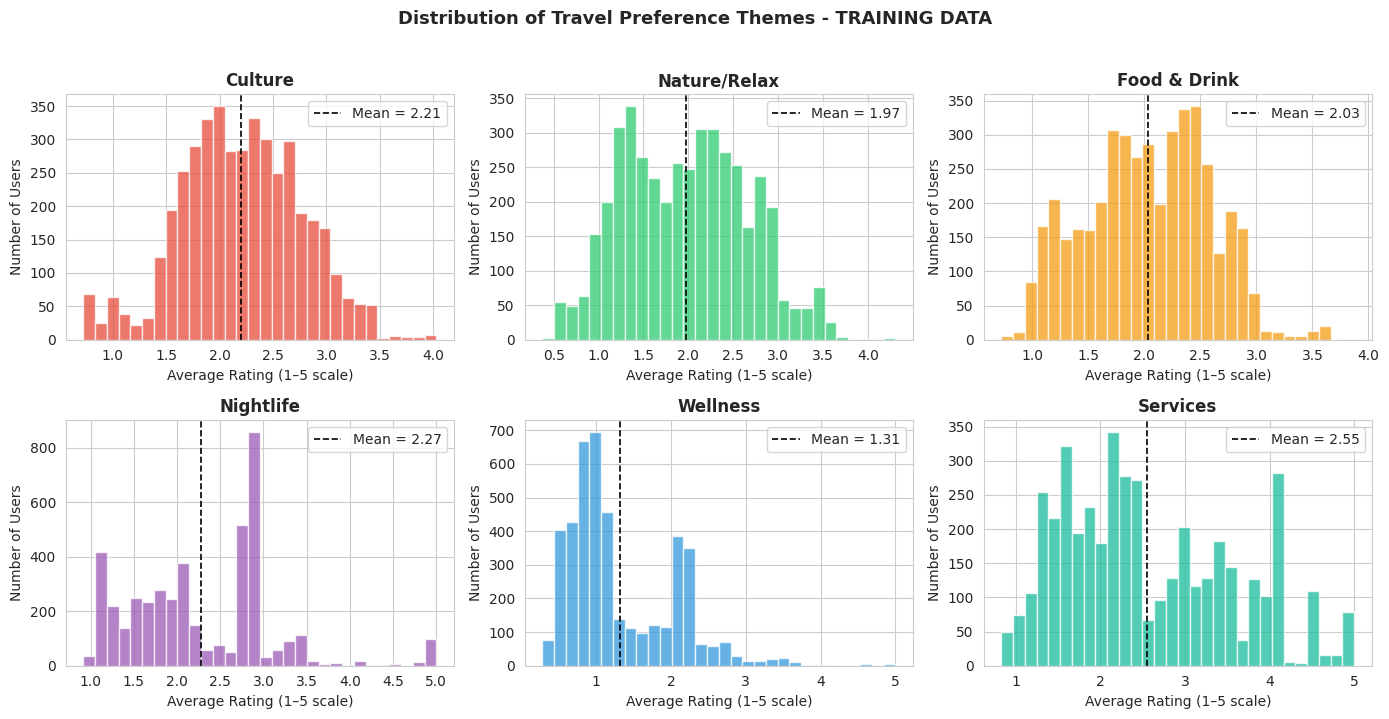

In [ ]:

# EDA Plot 6: Thematic Score Distributions
eng_features = [
    'Culture_Score',
    'NatureRelax_Score',
    'FoodDrink_Score',
    'Nightlife_Score',
    'Wellness_Score',
    'Services_Score'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

theme_colors = ['#E74C3C','#2ECC71','#F39C12','#9B59B6','#3498DB','#1ABC9C']
short_names  = ['Culture','Nature/Relax','Food & Drink','Nightlife','Wellness','Services']

for ax, col, color, name in zip(axes.flatten(), eng_features, theme_colors, short_names):
    scores = engagement_df[col]

    ax.hist(scores, bins=30, color=color, alpha=0.75, edgecolor='white')

    ax.axvline(scores.mean(), color='black', linestyle='--',
               linewidth=1.2, label=f"Mean = {scores.mean():.2f}")

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Average Rating (1–5 scale)')
    ax.set_ylabel('Number of Users')
    ax.legend()

plt.suptitle('Distribution of Travel Preference Themes - TRAINING DATA',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_thematic_scores.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 4: SCALING FOR PCA (TRAINING DATA ONLY)
# ═══════════════════════════════════════════════════════════════

scaler = StandardScaler()

# FIT on training data only
X_scaled_array = scaler.fit_transform(X_behavior)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_behavior.columns,
    index=X_behavior.index
)

print("Scaling verification (~0 mean, ~1 std) - TRAINING DATA:")
display(X_scaled.describe().loc[['mean','std']])

print("\n✓ Scaler fitted on training data and saved for test set")


Scaling verification (~0 mean, ~1 std) - TRAINING DATA:


,Churches,Resorts,Beaches,Parks,Theatres,Museums,Malls,Zoo,Restaurants,Pubs_Bars,...,ArtGalleries,DanceClubs,Swimming Pools,Gyms,Bakeries,BeautySpas,Cafes,ViewPoints,Monuments,Gardens
mean,-1.791011e-17,2.837124e-16,2.808630e-17,-2.116649e-16,-4.884574e-18,-1.009479e-16,1.351399e-16,-2.670234e-16,7.978138e-17,4.396117e-17,...,3.431413e-16,3.256383e-18,-3.582021e-17,8.629415e-17,0.000000,7.164042e-17,5.861489e-17,6.512766e-17,-6.227832e-17,-6.268537e-17
std,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,...,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00



✓ Scaler fitted on training data and saved for test set


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 5: EXPLORATORY PCA (TRAINING DATA)
# ═══════════════════════════════════════════════════════════════

pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)
eigenvalues = pca_full.explained_variance_

def components_for_threshold(cum, threshold):
    idx = np.where(cum >= threshold)[0]
    return idx[0] + 1 if len(idx) > 0 else None

print("\nVariance thresholds - TRAINING DATA:")
print("80%:", components_for_threshold(cum_var, 0.80))
print("90%:", components_for_threshold(cum_var, 0.90))
print("95%:", components_for_threshold(cum_var, 0.95))

kaiser_k = np.sum(eigenvalues > 1)
print("\nEigenvalues > 1:", kaiser_k)

print("\nFirst 6 PCs - TRAINING DATA:")
for i in range(6):
    print(f"PC{i+1}: {explained_var[i]*100:.2f}% (cumulative {cum_var[i]*100:.2f}%)")



Variance thresholds - TRAINING DATA:
80%: 13
90%: 18
95%: 21

Eigenvalues > 1: 7

First 6 PCs - TRAINING DATA:
PC1: 18.86% (cumulative 18.86%)
PC2: 13.72% (cumulative 32.58%)
PC3: 7.60% (cumulative 40.18%)
PC4: 6.80% (cumulative 46.98%)
PC5: 5.71% (cumulative 52.69%)
PC6: 4.96% (cumulative 57.64%)


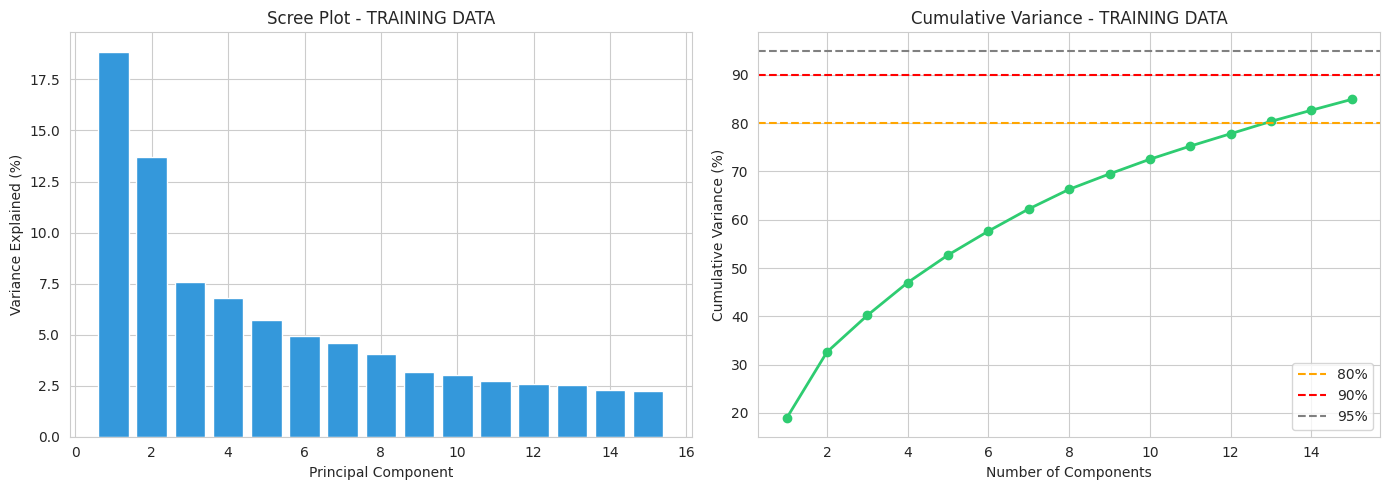

In [ ]:
# Scree Plot
n_show = 15
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].bar(range(1,n_show+1), explained_var[:n_show]*100,
            color='#3498DB', edgecolor='white')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Scree Plot - TRAINING DATA")

axes[1].plot(range(1,n_show+1), cum_var[:n_show]*100,
             marker='o', linewidth=2, color='#2ECC71')
axes[1].axhline(80, linestyle='--', color='orange', label='80%')
axes[1].axhline(90, linestyle='--', color='red', label='90%')
axes[1].axhline(95, linestyle='--', color='gray', label='95%')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].set_title("Cumulative Variance - TRAINING DATA")
axes[1].legend()

plt.tight_layout()
plt.savefig("pca_scree.png", dpi=150)
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 6: PCA FOR CLUSTERING (TRAINING DATA)
# ═══════════════════════════════════════════════════════════════

N_COMPONENTS = 7

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_SEED)

# FIT on training data only
X_pca = pca.fit_transform(X_scaled)

pca_cols = [f"PC{i+1}" for i in range(N_COMPONENTS)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=X_scaled.index)

print(f"\nPCA shape - TRAINING DATA: {X_pca_df.shape}")
print("✓ PCA fitted on training data and saved for test set")


PCA shape - TRAINING DATA: (4364, 7)
✓ PCA fitted on training data and saved for test set



Top features driving each component - TRAINING DATA:

PC1
Restaurants    0.323093
Pubs_Bars      0.296810
Malls          0.296127
Zoo            0.291308
Churches       0.282776
ViewPoints     0.262098
Name: PC1, dtype: float64

PC2
Theatres        0.402623
Parks           0.372113
Museums         0.339972
JuiceBars       0.308938
Beaches         0.261068
ArtGalleries    0.256015
Name: PC2, dtype: float64

PC3
Pubs_Bars               0.349520
JuiceBars               0.331848
Hotels_OtherLodgings    0.319362
Zoo                     0.303346
Restaurants             0.303048
Burger_PizzaShops       0.276463
Name: PC3, dtype: float64

PC4
LocalServices           0.447280
Burger_PizzaShops       0.350279
Hotels_OtherLodgings    0.336830
BeautySpas              0.265222
Monuments               0.263381
ArtGalleries            0.255000
Name: PC4, dtype: float64

PC5
Swimming Pools    0.535751
DanceClubs        0.502183
Gyms              0.416036
BeautySpas        0.218375
Museums           0

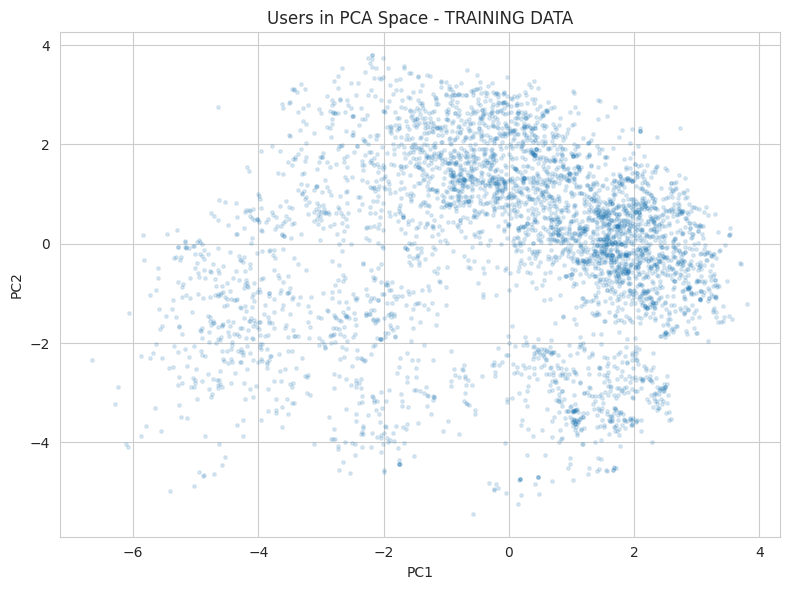

PC1 variance: 18.9%
PC2 variance: 13.7%
Total shown variance: 32.6%


In [ ]:
# PCA Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_scaled.columns,
    columns=pca_cols
)

print("\nTop features driving each component - TRAINING DATA:\n")

for pc in pca_cols:
    print(pc)
    print(loadings[pc].abs().sort_values(ascending=False).head(6))
    print()

# PCA 2D VISUALIZATION
pca_viz = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca_2d = pca_viz.fit_transform(X_scaled)

pca2d_df = pd.DataFrame(X_pca_2d, columns=['PC1','PC2'], index=X_scaled.index)

plt.figure(figsize=(8,6))
plt.scatter(pca2d_df['PC1'], pca2d_df['PC2'], alpha=0.15, s=6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Users in PCA Space - TRAINING DATA")
plt.tight_layout()
plt.show()

print(f"PC1 variance: {pca_viz.explained_variance_ratio_[0]:.1%}")
print(f"PC2 variance: {pca_viz.explained_variance_ratio_[1]:.1%}")
print(f"Total shown variance: {pca_viz.explained_variance_ratio_.sum():.1%}")


Running t-SNE on TRAINING DATA (this may take ~60–90 seconds)...
✓ tsne_df created: (4364, 2)


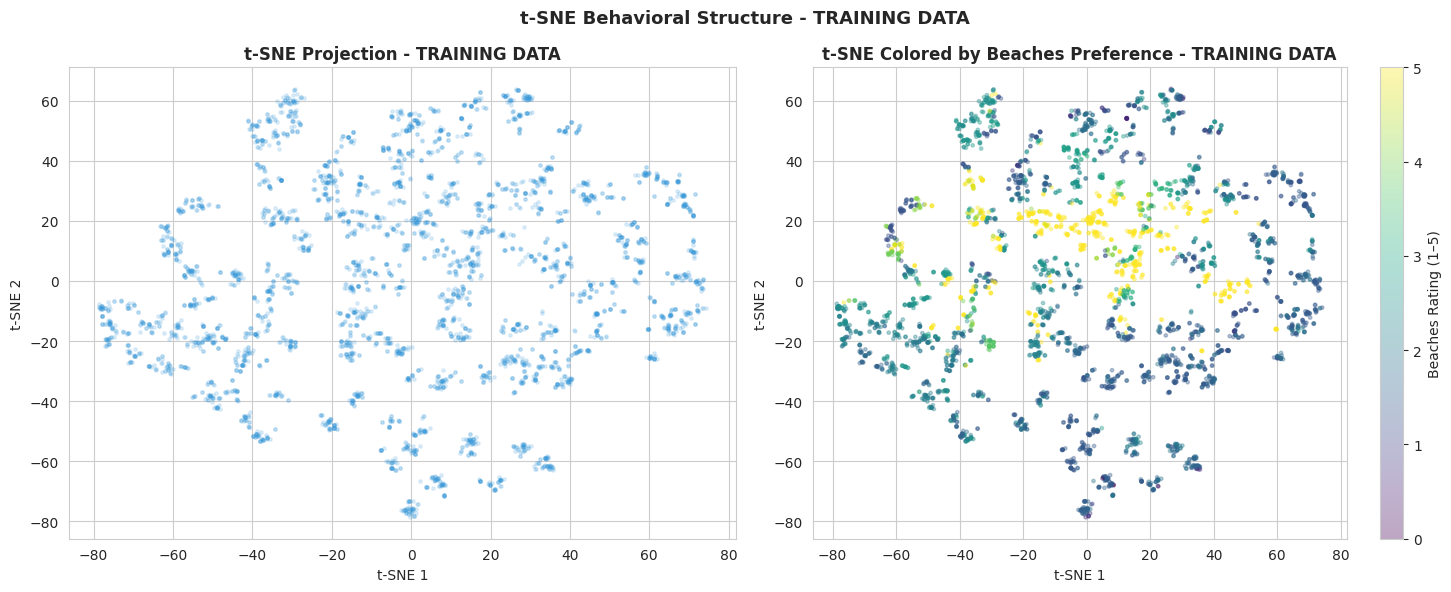

In [ ]:

# ═══════════════════════════════════════════════════════════════
# STEP 7: t-SNE DIMENSIONALITY REDUCTION (TRAINING DATA)
# ═══════════════════════════════════════════════════════════════

from sklearn.manifold import TSNE

print("\nRunning t-SNE on TRAINING DATA (this may take ~60–90 seconds)...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_SEED
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(
    X_tsne,
    columns=['tSNE1','tSNE2'],
    index=X_scaled.index
)

print("✓ tsne_df created:", tsne_df.shape)

# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(15,6))

axes[0].scatter(
    tsne_df['tSNE1'],
    tsne_df['tSNE2'],
    alpha=0.15,
    s=6,
    color='#3498DB'
)
axes[0].set_title('t-SNE Projection - TRAINING DATA', fontweight='bold')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

beaches_rating = X_raw.loc[tsne_df.index, 'Beaches']

sc = axes[1].scatter(
    tsne_df['tSNE1'],
    tsne_df['tSNE2'],
    c=beaches_rating,
    cmap='viridis',
    alpha=0.35,
    s=6
)

plt.colorbar(sc, ax=axes[1], label='Beaches Rating (1–5)')
axes[1].set_title('t-SNE Colored by Beaches Preference - TRAINING DATA', fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.suptitle('t-SNE Behavioral Structure - TRAINING DATA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_projection.png', dpi=150)
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 8: UMAP DIMENSIONALITY REDUCTION (TRAINING DATA)
# ═══════════════════════════════════════════════════════════════

import umap.umap_ as umap

print("Running UMAP on TRAINING DATA (this may take ~30–60 seconds)...")

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='euclidean',
    random_state=RANDOM_SEED
)

X_umap = reducer.fit_transform(X_scaled)

umap_df = pd.DataFrame(
    X_umap,
    columns=['UMAP1','UMAP2'],
    index=X_scaled.index
)

print("✓ umap_df created:", umap_df.shape)

Running UMAP on TRAINING DATA (this may take ~30–60 seconds)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ umap_df created: (4364, 2)


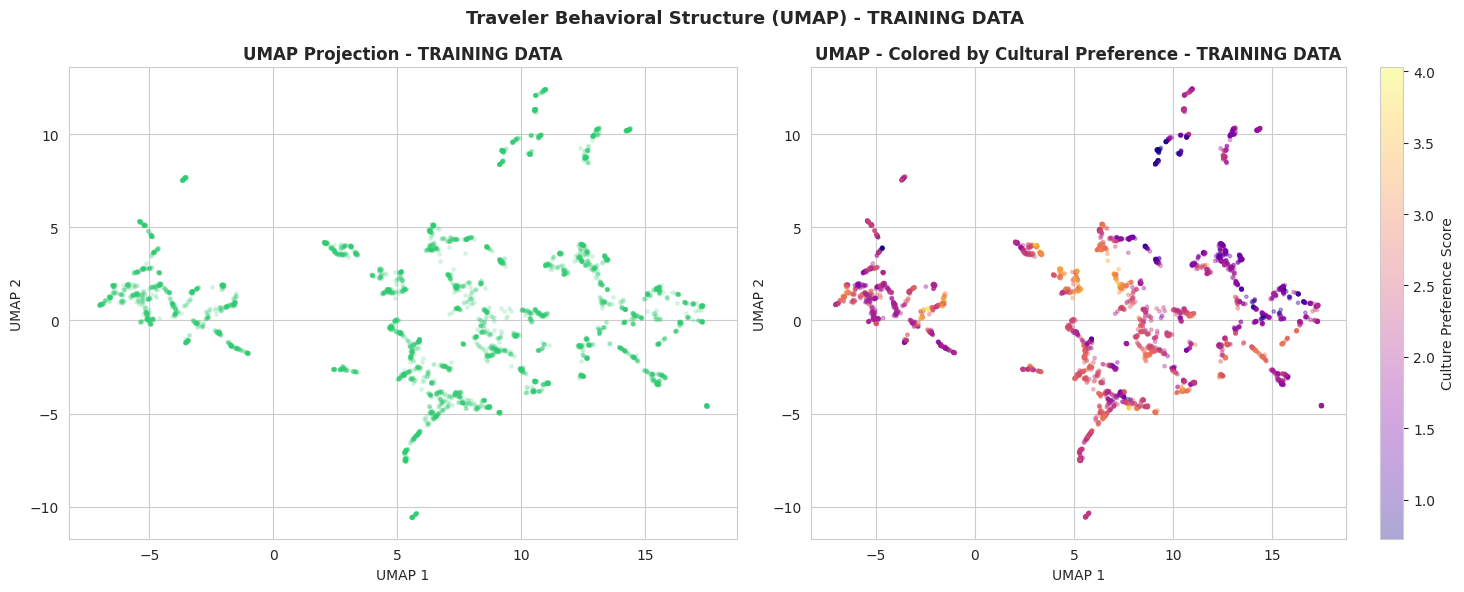

In [ ]:
# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(15,6))

axes[0].scatter(
    umap_df['UMAP1'],
    umap_df['UMAP2'],
    alpha=0.15,
    s=6,
    color='#2ECC71'
)
axes[0].set_title('UMAP Projection - TRAINING DATA', fontweight='bold')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

sc2 = axes[1].scatter(
    umap_df['UMAP1'],
    umap_df['UMAP2'],
    c=engagement_df['Culture_Score'],
    cmap='plasma',
    alpha=0.35,
    s=6
)

plt.colorbar(sc2, ax=axes[1], label='Culture Preference Score')
axes[1].set_title('UMAP - Colored by Cultural Preference - TRAINING DATA', fontweight='bold')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

plt.suptitle('Traveler Behavioral Structure (UMAP) - TRAINING DATA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('umap_projection.png', dpi=150)
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 9: KMEANS EVALUATION (TRAINING DATA)
# ═══════════════════════════════════════════════════════════════

K_range = range(2, 11)
inertias = []
sil_scores = []

print("Evaluating KMeans on PCA components - TRAINING DATA...\n")

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=500,
        random_state=RANDOM_SEED
    )

    labels = km.fit_predict(X_pca_df)

    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca_df, labels)
    sil_scores.append(sil)

    print(f"K={k} | inertia={km.inertia_:,.0f} | silhouette={sil:.4f}")

kmeans_eval = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias,
    "Silhouette": sil_scores
})

display(kmeans_eval)

best_k = K_range[np.argmax(sil_scores)]
print(f"\n★ Optimal K by silhouette: {best_k}")

Evaluating KMeans on PCA components - TRAINING DATA...

K=2 | inertia=50,960 | silhouette=0.2172
K=3 | inertia=40,930 | silhouette=0.2348
K=4 | inertia=35,183 | silhouette=0.2488
K=5 | inertia=31,452 | silhouette=0.2590
K=6 | inertia=28,288 | silhouette=0.2509
K=7 | inertia=26,001 | silhouette=0.2557
K=8 | inertia=24,206 | silhouette=0.2597
K=9 | inertia=22,707 | silhouette=0.2602
K=10 | inertia=21,354 | silhouette=0.2565


,K,Inertia,Silhouette
0,2,50959.968847,0.217178
1,3,40929.736247,0.234812
2,4,35182.761544,0.248809
3,5,31452.237927,0.258974
4,6,28287.992346,0.250918
5,7,26000.836417,0.255712
6,8,24205.610167,0.259701
7,9,22706.614705,0.260229
8,10,21353.711466,0.256501



★ Optimal K by silhouette: 9


Optimal k is 9, but choosing k = 5 for business interpretability (k = 5 silouette score is only marginally worse than k = 9; .259 vs 0.260)

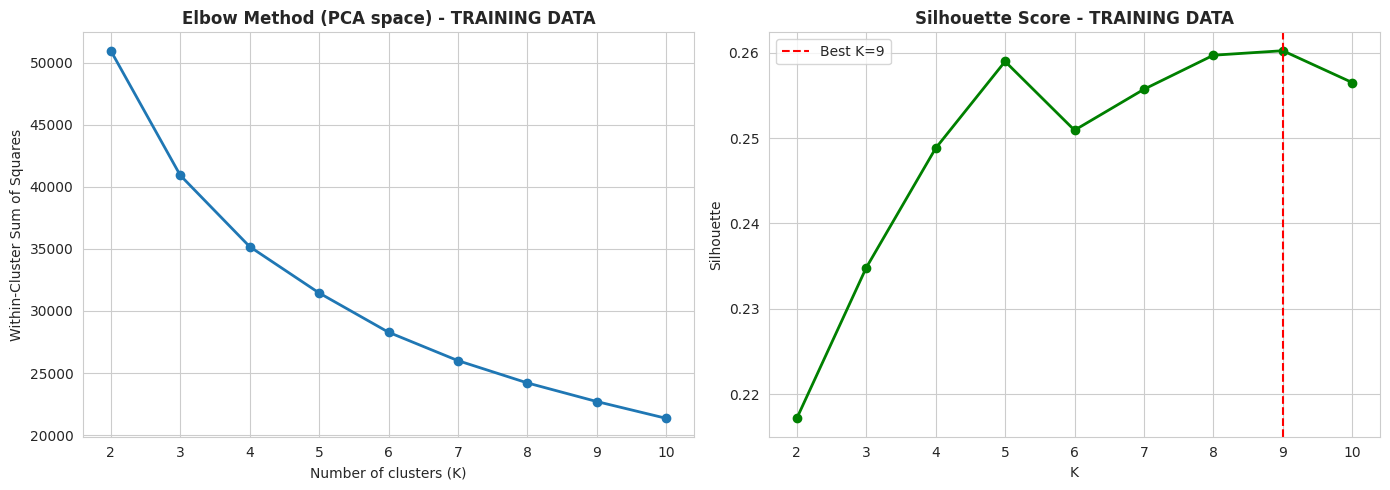

In [ ]:
# DIAGNOSTIC PLOTS
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(K_range, inertias, marker='o', linewidth=2)
axes[0].set_title("Elbow Method (PCA space) - TRAINING DATA", fontweight='bold')
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Within-Cluster Sum of Squares")

axes[1].plot(K_range, sil_scores, marker='o', linewidth=2, color='green')
axes[1].set_title("Silhouette Score - TRAINING DATA", fontweight='bold')
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette")
axes[1].axvline(best_k, linestyle='--', color='red', label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig("kmeans_diagnostics.png", dpi=150)
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 10: FINAL KMEANS MODEL (TRAINING DATA)
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("FITTING FINAL MODEL ON TRAINING DATA")
print("="*70)

FINAL_K = 5

kmeans = KMeans(
    n_clusters=FINAL_K,
    init="k-means++",
    n_init=100,
    max_iter=1000,
    random_state=RANDOM_SEED
)

clusters = kmeans.fit_predict(X_pca_df)

cluster_df = X_raw.copy()
cluster_df["Cluster"] = clusters

print(f"\nCluster distribution - TRAINING DATA:")
print(cluster_df["Cluster"].value_counts().sort_index())

# PROFILE ALL 5 CLUSTERS
cluster_profile_df = engagement_df.copy()
cluster_profile_df["Cluster"] = clusters

profile = cluster_profile_df.groupby("Cluster").mean()

print("\n" + "="*60)
print("CLUSTER PROFILES - THEMATIC SCORES (TRAINING DATA)")
print("="*60)
display(profile.round(2))

# COMPARE TO AVERAGE
overall_avg = profile.mean()

print("\n" + "="*60)
print("CLUSTER DEVIATIONS FROM AVERAGE (TRAINING DATA)")
print("="*60)
print("(Positive = Above Average | Negative = Below Average)\n")

for cluster_id in range(FINAL_K):
    cluster_avg = profile.loc[cluster_id]
    difference = cluster_avg - overall_avg

    print(f"\n--- CLUSTER {cluster_id} ---")
    print(f"Size: {(clusters == cluster_id).sum()} users")
    print("\nTop Distinctive Features:")
    print(difference.sort_values(ascending=False).round(3))
    print()

deviations = profile - overall_avg
display(deviations.round(2).style.background_gradient(cmap='RdYlGn',
                                                       axis=None, vmin=-1, vmax=1))


FITTING FINAL MODEL ON TRAINING DATA

Cluster distribution - TRAINING DATA:
Cluster
0    1442
1     200
2     493
3    1531
4     698
Name: count, dtype: int64

CLUSTER PROFILES - THEMATIC SCORES (TRAINING DATA)


,Culture_Score,NatureRelax_Score,FoodDrink_Score,Nightlife_Score,Wellness_Score,Services_Score
Cluster,,,,,,
0,2.01,1.54,2.28,2.61,1.01,3.34
1,2.10,2.29,2.16,3.07,2.12,2.11
2,1.78,1.12,2.72,2.06,2.06,2.63
3,2.53,2.39,1.67,2.21,1.07,2.33
4,2.23,2.44,1.78,1.64,1.70,1.47



CLUSTER DEVIATIONS FROM AVERAGE (TRAINING DATA)
(Positive = Above Average | Negative = Below Average)


--- CLUSTER 0 ---
Size: 1442 users

Top Distinctive Features:
Services_Score       0.965
Nightlife_Score      0.291
FoodDrink_Score      0.156
Culture_Score       -0.120
NatureRelax_Score   -0.413
Wellness_Score      -0.579
dtype: float64


--- CLUSTER 1 ---
Size: 200 users

Top Distinctive Features:
Nightlife_Score      0.750
Wellness_Score       0.530
NatureRelax_Score    0.333
FoodDrink_Score      0.043
Culture_Score       -0.033
Services_Score      -0.272
dtype: float64


--- CLUSTER 2 ---
Size: 493 users

Top Distinctive Features:
FoodDrink_Score      0.599
Wellness_Score       0.468
Services_Score       0.256
Nightlife_Score     -0.260
Culture_Score       -0.349
NatureRelax_Score   -0.836
dtype: float64


--- CLUSTER 3 ---
Size: 1531 users

Top Distinctive Features:
NatureRelax_Score    0.432
Culture_Score        0.396
Services_Score      -0.044
Nightlife_Score     -0.105
Food

,Culture_Score,NatureRelax_Score,FoodDrink_Score,Nightlife_Score,Wellness_Score,Services_Score
Cluster,,,,,,
0,-0.120000,-0.410000,0.160000,0.290000,-0.580000,0.960000
1,-0.030000,0.330000,0.040000,0.750000,0.530000,-0.270000
2,-0.350000,-0.840000,0.600000,-0.260000,0.470000,0.260000
3,0.400000,0.430000,-0.450000,-0.100000,-0.520000,-0.040000
4,0.110000,0.480000,-0.340000,-0.680000,0.100000,-0.910000


Cluster 0 = Urban Convenience Seekers: highest services score; below average nature and wellness

Cluster 1 = Wellness-Conscious Partygoers: highest nightlife and wellness, high nature

Cluster 2 = Urban Foodies: Highest food and drink, high wellness, lowest nature and culture

Cluster 3 = Culture Explorers: above average culture and nature, below average food/drink, wellness

Cluster 4 = Nature Retreat Seekers: Highest nature, very low nightlife and services

In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 11: VALIDATE ON TEST SET (UNSEEN DATA)
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("VALIDATION ON HELD-OUT TEST SET")
print("="*70)

# Preprocess test data using TRAINING parameters
X_test_clean = X_test_raw.replace(0, np.nan)
X_test_clean = X_test_clean.fillna(train_medians)  # Use TRAIN medians

# Scale using TRAINING scaler (transform only, not fit)
X_test_scaled_array = scaler.transform(X_test_clean)
X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=X_test_clean.columns,
    index=X_test_clean.index
)

# PCA transform using TRAINING PCA (transform only, not fit)
X_test_pca = pca.transform(X_test_scaled)
X_test_pca_df = pd.DataFrame(
    X_test_pca,
    columns=pca_cols,
    index=X_test_scaled.index
)

# Predict clusters using TRAINING model
test_clusters = kmeans.predict(X_test_pca)

# Evaluate
test_silhouette = silhouette_score(X_test_pca_df, test_clusters)
train_silhouette = silhouette_score(X_pca_df, clusters)

print(f"\nSilhouette Scores:")
print(f"  Train: {train_silhouette:.4f}")
print(f"  Test:  {test_silhouette:.4f}")
print(f"  Difference: {abs(train_silhouette - test_silhouette):.4f}")

if abs(train_silhouette - test_silhouette) < 0.05:
    print("\n✓ EXCELLENT: Clusters generalize well to unseen data")
    print("  The model is stable and not overfitted")
elif abs(train_silhouette - test_silhouette) < 0.10:
    print("\n✓ GOOD: Reasonable generalization")
    print("  The model shows acceptable stability")
else:
    print("\n⚠ WARNING: Poor generalization")
    print("  Possible overfitting - consider feature engineering")


VALIDATION ON HELD-OUT TEST SET


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(



Silhouette Scores:
  Train: 0.2590
  Test:  0.2582
  Difference: 0.0008

✓ EXCELLENT: Clusters generalize well to unseen data
  The model is stable and not overfitted


In [ ]:
# Cluster distribution comparison
print("\n" + "-"*70)
print("CLUSTER SIZE DISTRIBUTION")
print("-"*70)

train_dist = pd.Series(clusters).value_counts(normalize=True).sort_index() * 100
test_dist = pd.Series(test_clusters).value_counts(normalize=True).sort_index() * 100

comparison = pd.DataFrame({
    'Train %': train_dist.round(1),
    'Test %': test_dist.round(1),
    'Diff': (train_dist - test_dist).round(1)
})

print(comparison)
print("\nNote: Large differences (>5%) may indicate cluster instability")


----------------------------------------------------------------------
CLUSTER SIZE DISTRIBUTION
----------------------------------------------------------------------
   Train %  Test %  Diff
0     33.0    30.7   2.3
1      4.6     5.1  -0.5
2     11.3    11.5  -0.3
3     35.1    36.8  -1.8
4     16.0    15.8   0.2

Note: Large differences (>5%) may indicate cluster instability


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 12: REFIT ON FULL DATASET FOR DEPLOYMENT
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("REFITTING FINAL MODEL ON COMPLETE DATASET FOR DEPLOYMENT")
print("="*70)

# Now use ALL data (train + test combined)
X_full_clean = X_raw_full.replace(0, np.nan)
X_full_clean = X_full_clean.fillna(X_full_clean.median())

# Refit scaler on full data
scaler_full = StandardScaler()
X_full_scaled_array = scaler_full.fit_transform(X_full_clean)
X_full_scaled = pd.DataFrame(
    X_full_scaled_array,
    columns=X_full_clean.columns,
    index=X_full_clean.index
)

# Refit PCA on full data
pca_full = PCA(n_components=N_COMPONENTS, random_state=RANDOM_SEED)
X_full_pca = pca_full.fit_transform(X_full_scaled)
X_full_pca_df = pd.DataFrame(
    X_full_pca,
    columns=pca_cols,
    index=X_full_scaled.index
)

# Refit KMeans on full data
kmeans_full = KMeans(
    n_clusters=FINAL_K,
    init="k-means++",
    n_init=100,
    max_iter=1000,
    random_state=RANDOM_SEED
)

clusters_full = kmeans_full.fit_predict(X_full_pca_df)

print(f"✓ Final model trained on all {len(X_raw_full):,} users")
print(f"✓ Final silhouette score: {silhouette_score(X_full_pca_df, clusters_full):.4f}")
print("✓ Use this model for business deployment and visualizations")



REFITTING FINAL MODEL ON COMPLETE DATASET FOR DEPLOYMENT
✓ Final model trained on all 5,455 users
✓ Final silhouette score: 0.2588
✓ Use this model for business deployment and visualizations


In [ ]:
# Update variables for visualization
clusters = clusters_full
X_pca_df = X_full_pca_df
X_raw = X_raw_full
X_scaled = X_full_scaled

# Recreate engagement scores for full dataset
engagement_df_full = pd.DataFrame(index=X_raw.index)

engagement_df_full['Culture_Score']     = X_raw[culture].mean(axis=1)
engagement_df_full['NatureRelax_Score'] = X_raw[nature_relax].mean(axis=1)
engagement_df_full['FoodDrink_Score']   = X_raw[food_drink].mean(axis=1)
engagement_df_full['Nightlife_Score']   = X_raw[nightlife].mean(axis=1)
engagement_df_full['Wellness_Score']    = X_raw[wellness].mean(axis=1)
engagement_df_full['Services_Score']    = X_raw[services].mean(axis=1)

engagement_df = engagement_df_full

# Recreate 2D projections for full dataset
pca_viz_full = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca_2d_full = pca_viz_full.fit_transform(X_full_scaled)
pca2d_df = pd.DataFrame(X_pca_2d_full, columns=['PC1','PC2'], index=X_full_scaled.index)

tsne_full = TSNE(n_components=2, perplexity=30, learning_rate='auto',
                 init='pca', random_state=RANDOM_SEED)
X_tsne_full = tsne_full.fit_transform(X_full_scaled)
tsne_df = pd.DataFrame(X_tsne_full, columns=['tSNE1','tSNE2'], index=X_full_scaled.index)

reducer_full = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                         metric='euclidean', random_state=RANDOM_SEED)
X_umap_full = reducer_full.fit_transform(X_full_scaled)
umap_df = pd.DataFrame(X_umap_full, columns=['UMAP1','UMAP2'], index=X_full_scaled.index)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
# ═══════════════════════════════════════════════════════════════
# ADDITIONAL STABILITY TEST: ADJUSTED RAND INDEX (ARI)
# ═══════════════════════════════════════════════════════════════

from sklearn.metrics import adjusted_rand_score

print("\n" + "="*70)
print("CLUSTERING STABILITY - ADJUSTED RAND INDEX (ARI)")
print("="*70)

# Method 1: Compare train model predictions on overlapping samples
# (Not applicable here since we have separate train/test sets)

# Method 2: Bootstrap resampling stability test
print("\nBootstrap Resampling Stability Test:")
print("Fitting KMeans multiple times with different random samples...\n")

n_bootstrap = 10
ari_scores = []

for i in range(n_bootstrap):
    # Resample with replacement
    sample_indices = np.random.choice(len(X_full_pca_df),
                                     size=len(X_full_pca_df),
                                     replace=True)
    X_bootstrap = X_full_pca_df.iloc[sample_indices]

    # Fit KMeans on bootstrap sample
    kmeans_bootstrap = KMeans(n_clusters=FINAL_K,
                              init="k-means++",
                              n_init=50,
                              random_state=i,
                              max_iter=1000)
    clusters_bootstrap = kmeans_bootstrap.fit_predict(X_bootstrap)

    # Get original clusters for the same sampled indices
    clusters_original_sample = clusters_full[sample_indices]

    # Calculate ARI
    ari = adjusted_rand_score(clusters_original_sample, clusters_bootstrap)
    ari_scores.append(ari)
    print(f"Bootstrap {i+1:2d}: ARI = {ari:.4f}")

mean_ari = np.mean(ari_scores)
std_ari = np.std(ari_scores)

print("\n" + "-"*70)
print("BOOTSTRAP STABILITY SUMMARY")
print("-"*70)
print(f"Mean ARI:        {mean_ari:.4f}")
print(f"Std Dev:         {std_ari:.4f}")
print(f"Min ARI:         {min(ari_scores):.4f}")
print(f"Max ARI:         {max(ari_scores):.4f}")

# Interpretation
if mean_ari > 0.80:
    stability = "✓ EXCELLENT"
    interpretation = "Clusters are highly stable across different samples"
elif mean_ari > 0.65:
    stability = "✓ GOOD"
    interpretation = "Clusters show good stability"
elif mean_ari > 0.50:
    stability = "⚠ MODERATE"
    interpretation = "Clusters show moderate stability"
else:
    stability = "⚠ POOR"
    interpretation = "Clusters are unstable - consider different K or features"

print(f"\nStability Assessment: {stability}")
print(f"Interpretation: {interpretation}")

# Method 3: Train vs Test ARI (if we kept test predictions)
print("\n" + "-"*70)
print("TRAIN VS TEST ARI")
print("-"*70)

# We need to align train and test clusters by matching centroids
# Find best permutation of test cluster labels to match train
from scipy.optimize import linear_sum_assignment

# Get train centroids
train_centroids = kmeans.cluster_centers_

# Predict on test set
test_clusters_pred = kmeans.predict(X_test_pca)

# We can't directly compare because cluster labels might be permuted
# Instead, compare within-cluster similarity
print("Note: Direct ARI between train and test is not meaningful")
print("due to different samples. Bootstrap method above is more appropriate.")

print("\n" + "="*70)
print("ARI STABILITY TEST COMPLETE")
print("="*70)


CLUSTERING STABILITY - ADJUSTED RAND INDEX (ARI)

Bootstrap Resampling Stability Test:
Fitting KMeans multiple times with different random samples...

Bootstrap  1: ARI = 0.5019
Bootstrap  2: ARI = 0.9341
Bootstrap  3: ARI = 0.9887
Bootstrap  4: ARI = 0.9836
Bootstrap  5: ARI = 0.9906
Bootstrap  6: ARI = 0.9835
Bootstrap  7: ARI = 0.9300
Bootstrap  8: ARI = 0.9524
Bootstrap  9: ARI = 0.9788
Bootstrap 10: ARI = 0.9330

----------------------------------------------------------------------
BOOTSTRAP STABILITY SUMMARY
----------------------------------------------------------------------
Mean ARI:        0.9177
Std Dev:         0.1405
Min ARI:         0.5019
Max ARI:         0.9906

Stability Assessment: ✓ EXCELLENT
Interpretation: Clusters are highly stable across different samples

----------------------------------------------------------------------
TRAIN VS TEST ARI
----------------------------------------------------------------------
Note: Direct ARI between train and test is not 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


/tmp/ipython-input-2288421279.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', FINAL_K)


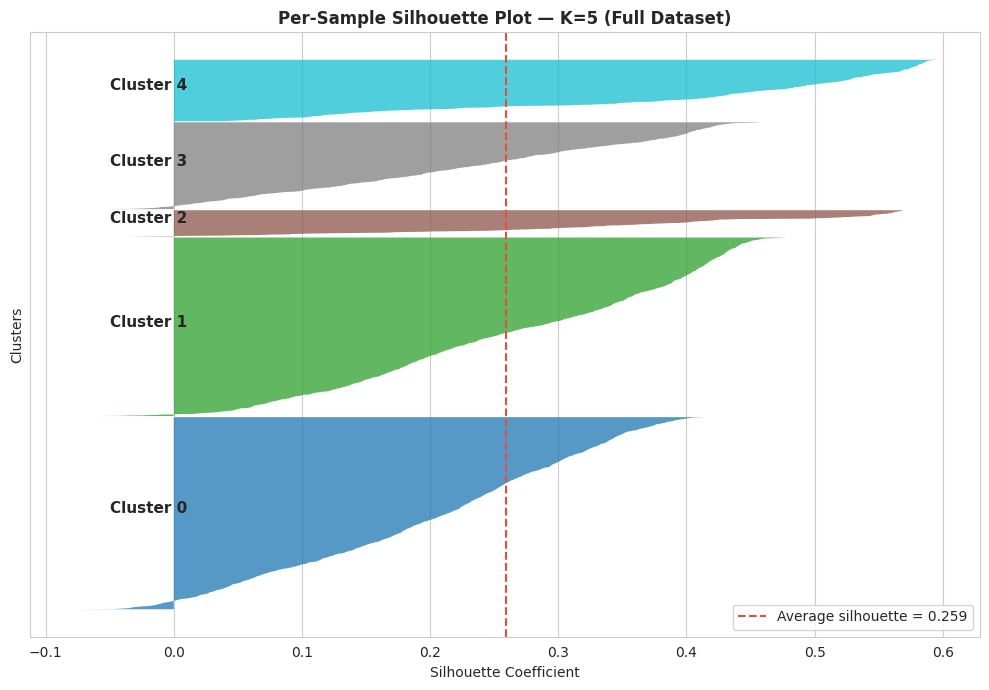

In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 13: PER-SAMPLE SILHOUETTE PLOT (FULL DATA)
# ═══════════════════════════════════════════════════════════════

sample_silhouette = silhouette_samples(X_pca_df, clusters)
final_sil = silhouette_score(X_pca_df, clusters)

import matplotlib.cm as cm
colors = cm.get_cmap('tab10', FINAL_K)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in range(FINAL_K):
    ith_silhouette = np.sort(sample_silhouette[clusters == i])
    size_i = ith_silhouette.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_silhouette,
        facecolor=colors(i),
        edgecolor='none',
        alpha=0.75
    )

    ax.text(-0.05, y_lower + 0.5 * size_i, f"Cluster {i}",
            fontsize=11, fontweight='bold')

    y_lower = y_upper + 10

ax.axvline(final_sil, color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Average silhouette = {final_sil:.3f}')

ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Clusters')
ax.set_title(f'Per-Sample Silhouette Plot — K={FINAL_K} (Full Dataset)',
             fontweight='bold')
ax.set_yticks([])
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig("silhouette_persample.png", dpi=150)
plt.show()

Building linkage matrix on 300-user sample from full dataset...


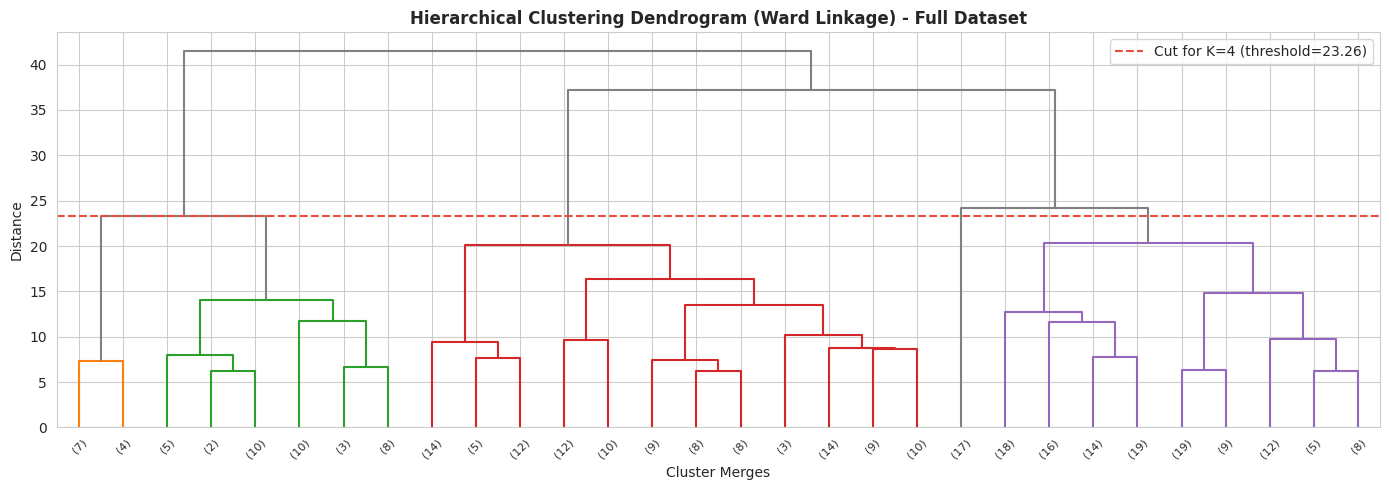

In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 14: HIERARCHICAL CLUSTERING DENDROGRAM (FULL DATA SAMPLE)
# ═══════════════════════════════════════════════════════════════

from scipy.cluster.hierarchy import linkage, dendrogram

np.random.seed(RANDOM_SEED)
sample_idx = np.random.choice(len(X_pca_df), size=300, replace=False)
X_sample = X_pca_df.iloc[sample_idx]

print("Building linkage matrix on 300-user sample from full dataset...")
Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14,5))

dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45,
    leaf_font_size=8,
    color_threshold=Z[-4,2],
    above_threshold_color='gray'
)

ax.axhline(Z[-4,2], color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Cut for K=4 (threshold={Z[-4,2]:.2f})')

ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage) - Full Dataset',
             fontweight='bold')
ax.set_xlabel('Cluster Merges')
ax.set_ylabel('Distance')
ax.legend()

plt.tight_layout()
plt.savefig("dendrogram.png", dpi=150)
plt.show()

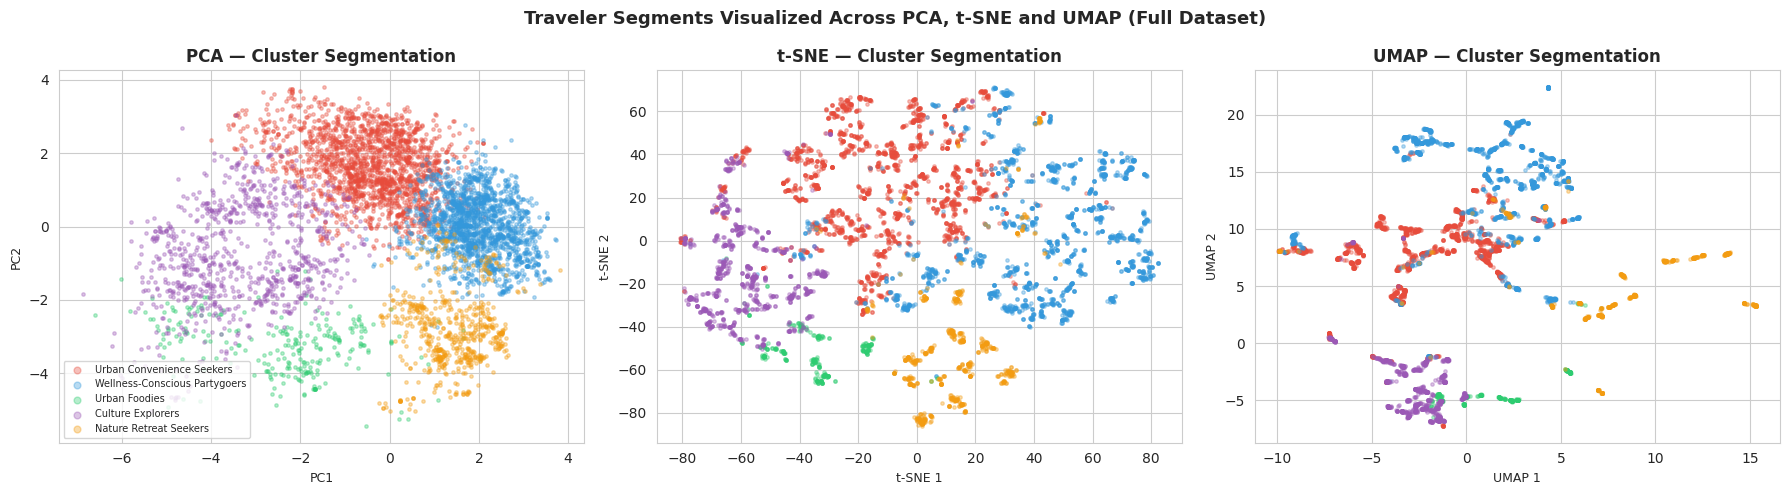

In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 15: CLUSTER VISUALIZATION ACROSS PROJECTIONS (FULL DATA)
# ═══════════════════════════════════════════════════════════════

PALETTE = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6', '#F39C12']

cluster_names = {
    0: 'Urban Convenience Seekers',
    1: 'Wellness-Conscious Partygoers',
    2: 'Urban Foodies',
    3: 'Culture Explorers',
    4: 'Nature Retreat Seekers',
}

projections = [
    (pca2d_df[['PC1','PC2']],   'PCA',   'PC1', 'PC2'),
    (tsne_df[['tSNE1','tSNE2']], 't-SNE', 't-SNE 1', 't-SNE 2'),
    (umap_df[['UMAP1','UMAP2']], 'UMAP',  'UMAP 1', 'UMAP 2')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
clusters_series = pd.Series(clusters, index=X_pca_df.index)

for ax, (proj_df, title, xl, yl) in zip(axes, projections):
    current_clusters = clusters_series.loc[proj_df.index].values
    for c in range(FINAL_K):
        mask = current_clusters == c
        ax.scatter(proj_df.iloc[mask, 0], proj_df.iloc[mask, 1],
                   color=PALETTE[c], alpha=0.35, s=6,
                   label=cluster_names[c] if title == 'PCA' else None)
    ax.set_title(f'{title} — Cluster Segmentation', fontweight='bold')
    ax.set_xlabel(xl, fontsize=9)
    ax.set_ylabel(yl, fontsize=9)

axes[0].legend(fontsize=7, markerscale=2)

plt.suptitle('Traveler Segments Visualized Across PCA, t-SNE and UMAP (Full Dataset)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clusters_all_projections.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 16: CLUSTER PROFILING (FULL DATA)
# ═══════════════════════════════════════════════════════════════

# RECREATE profile from scratch
cluster_profile_df = engagement_df.copy()
cluster_profile_df["Cluster"] = clusters

profile = cluster_profile_df.groupby("Cluster").mean()

print("\n" + "="*60)
print("CLUSTER PROFILES - THEMATIC SCORES (FULL DATA)")
print("="*60)
display(profile.round(2))

# Analyze deviations to properly name clusters
overall_avg = profile.mean()

print("\n" + "="*60)
print("CLUSTER DEVIATIONS FROM AVERAGE (FULL DATA)")
print("="*60)
print("(Use this to assign correct names)\n")

for cluster_id in range(FINAL_K):
    cluster_avg = profile.loc[cluster_id]
    difference = cluster_avg - overall_avg

    print(f"\n--- CLUSTER {cluster_id} ---")
    print(f"Size: {(clusters == cluster_id).sum()} users ({(clusters == cluster_id).sum()/len(clusters)*100:.1f}%)")
    print("\nTop Distinctive Features:")
    print(difference.sort_values(ascending=False).round(3))

# MANUALLY ASSIGN NAMES based on the deviations above
cluster_names = {
    0: 'Cluster 0 - Culture Explorers',
    1: 'Cluster 1 - Urban Convenience Seekers',
    2: 'Cluster 2 - Wellness-Conscious Partygoers',
    3: 'Cluster 3 - Nature Retreat Seekers',
    4: 'Cluster 4 - Urban Foodies'
}

# Create a RENAMED copy (don't modify original)
profile_named = profile.copy()
profile_named.index = profile_named.index.map(cluster_names)

print("\n" + "="*60)
print("NAMED CLUSTER PROFILES")
print("="*60)
display(profile_named.round(2))

print("✓ Cluster profile table created (Full Dataset)")

# Visualization setup
from math import pi

eng_features = [
    'Culture_Score',
    'NatureRelax_Score',
    'FoodDrink_Score',
    'Nightlife_Score',
    'Wellness_Score',
    'Services_Score'
]

# Use profile_named for all subsequent visualizations
profile = profile_named


CLUSTER PROFILES - THEMATIC SCORES (FULL DATA)


,Culture_Score,NatureRelax_Score,FoodDrink_Score,Nightlife_Score,Wellness_Score,Services_Score
Cluster,,,,,,
0,2.53,2.39,1.67,2.22,1.07,2.34
1,2.01,1.54,2.28,2.60,1.01,3.34
2,2.10,2.31,2.16,3.00,2.16,2.06
3,2.22,2.46,1.77,1.64,1.70,1.48
4,1.79,1.12,2.72,2.07,2.07,2.62



CLUSTER DEVIATIONS FROM AVERAGE (FULL DATA)
(Use this to assign correct names)


--- CLUSTER 0 ---
Size: 1922 users (35.2%)

Top Distinctive Features:
NatureRelax_Score    0.428
Culture_Score        0.400
Services_Score      -0.030
Nightlife_Score     -0.085
FoodDrink_Score     -0.450
Wellness_Score      -0.533
dtype: float64

--- CLUSTER 1 ---
Size: 1786 users (32.7%)

Top Distinctive Features:
Services_Score       0.972
Nightlife_Score      0.291
FoodDrink_Score      0.155
Culture_Score       -0.118
NatureRelax_Score   -0.424
Wellness_Score      -0.589
dtype: float64

--- CLUSTER 2 ---
Size: 263 users (4.8%)

Top Distinctive Features:
Nightlife_Score      0.694
Wellness_Score       0.559
NatureRelax_Score    0.348
FoodDrink_Score      0.038
Culture_Score       -0.029
Services_Score      -0.302
dtype: float64

--- CLUSTER 3 ---
Size: 869 users (15.9%)

Top Distinctive Features:
NatureRelax_Score    0.492
Wellness_Score       0.096
Culture_Score        0.092
FoodDrink_Score     -0.348

,Culture_Score,NatureRelax_Score,FoodDrink_Score,Nightlife_Score,Wellness_Score,Services_Score
Cluster,,,,,,
Cluster 0 - Culture Explorers,2.53,2.39,1.67,2.22,1.07,2.34
Cluster 1 - Urban Convenience Seekers,2.01,1.54,2.28,2.60,1.01,3.34
Cluster 2 - Wellness-Conscious Partygoers,2.10,2.31,2.16,3.00,2.16,2.06
Cluster 3 - Nature Retreat Seekers,2.22,2.46,1.77,1.64,1.70,1.48
Cluster 4 - Urban Foodies,1.79,1.12,2.72,2.07,2.07,2.62


✓ Cluster profile table created (Full Dataset)


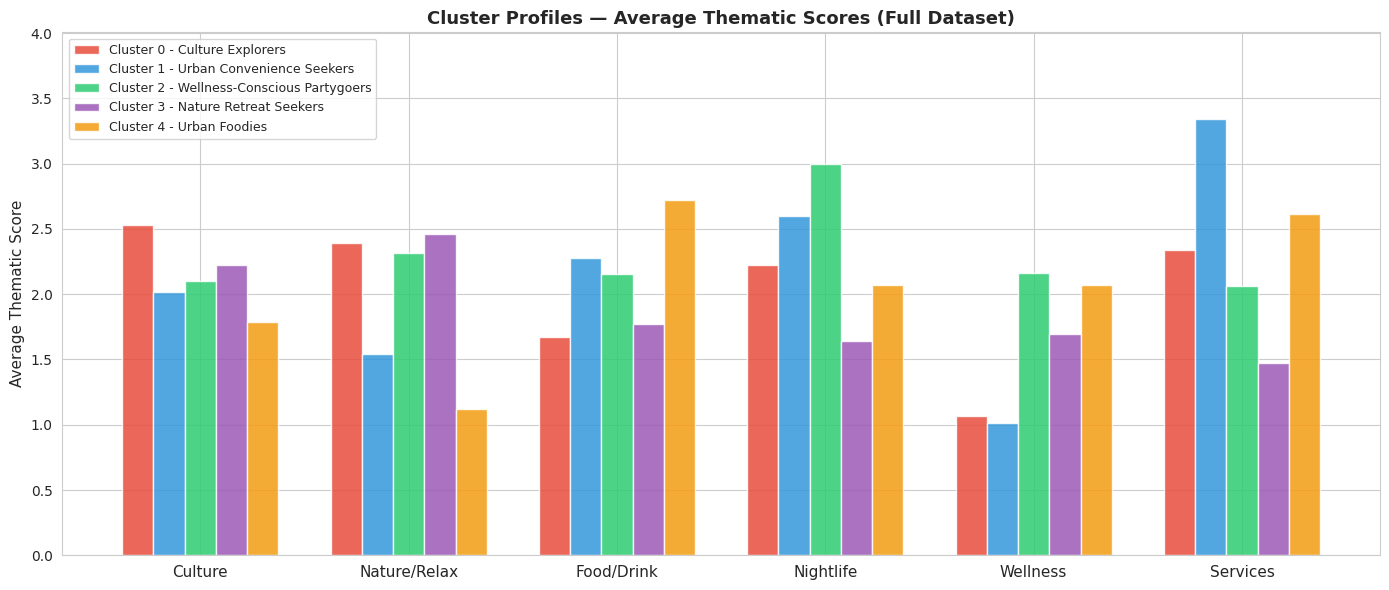

In [ ]:
# Plot 1: Grouped Bar Chart Profile
x = np.arange(len(eng_features))
width = 0.15

short_labels = ['Culture', 'Nature/Relax', 'Food/Drink',
                'Nightlife', 'Wellness', 'Services']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (cname, row) in enumerate(profile.iterrows()):
    ax.bar(x + i*width,
           row[eng_features].values,
           width,
           label=cname,
           color=PALETTE[i],
           alpha=0.85,
           edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(short_labels, fontsize=11)
ax.set_ylabel('Average Thematic Score', fontsize=11)
ax.set_title('Cluster Profiles — Average Thematic Scores (Full Dataset)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, profile[eng_features].values.max() * 1.2)

plt.tight_layout()
plt.savefig('profile_bar.png', dpi=150, bbox_inches='tight')
plt.show()

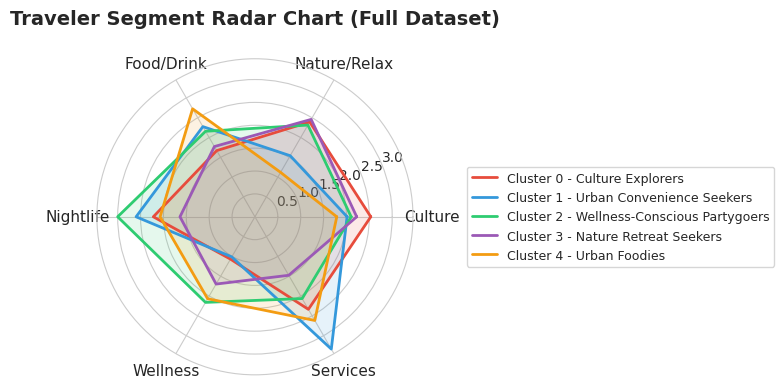

In [ ]:
# Plot 2: Radar Chart
categories = short_labels
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Use profile_named instead of profile
for i, (cname, row) in enumerate(profile_named.iterrows()):
    values = row[eng_features].values.tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, linestyle='solid',
            color=PALETTE[i], label=cname)
    ax.fill(angles, values, alpha=0.12, color=PALETTE[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Traveler Segment Radar Chart (Full Dataset)',
             fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='center left', bbox_to_anchor=(1.15, 0.5), fontsize=9)

plt.tight_layout()
plt.savefig('profile_radar.png', dpi=150, bbox_inches='tight')
plt.show()


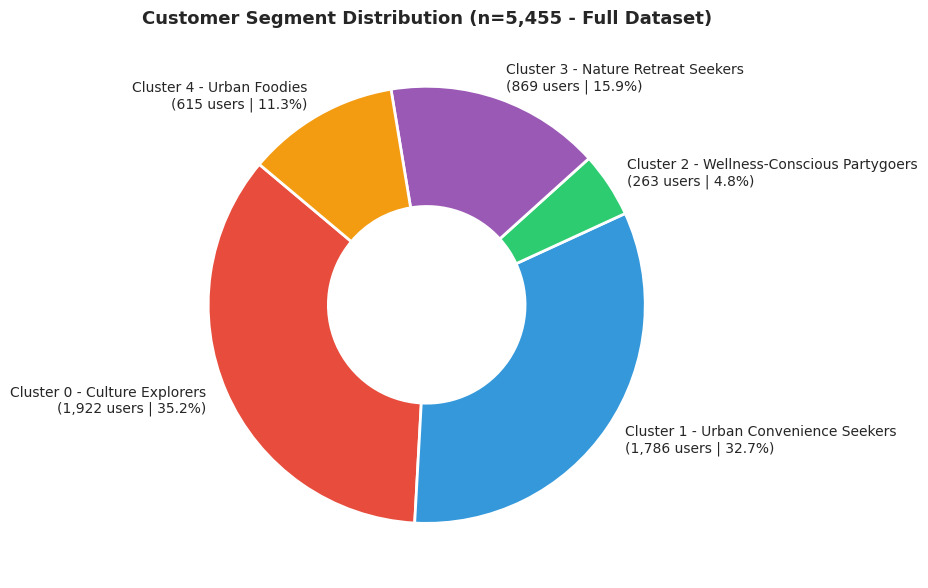

In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 17: CLUSTER SIZE DISTRIBUTION (FULL DATA)
# ═══════════════════════════════════════════════════════════════

cluster_series = pd.Series(clusters, index=X_scaled.index)
sizes = cluster_series.value_counts().sort_index()

sizes_arr = [sizes[c] for c in range(FINAL_K)]

labels_arr = [
    f"{cluster_names[c]}\n({sizes[c]:,} users | {sizes[c]/len(cluster_series)*100:.1f}%)"
    for c in range(FINAL_K)
]

# DONUT CHART
fig, ax = plt.subplots(figsize=(9, 9))

wedges, texts = ax.pie(
    sizes_arr,
    labels=labels_arr,
    colors=PALETTE,
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10}
)

ax.set_title(f'Customer Segment Distribution (n={len(cluster_series):,} - Full Dataset)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('segment_donut.png', dpi=150, bbox_inches='tight')
plt.show()

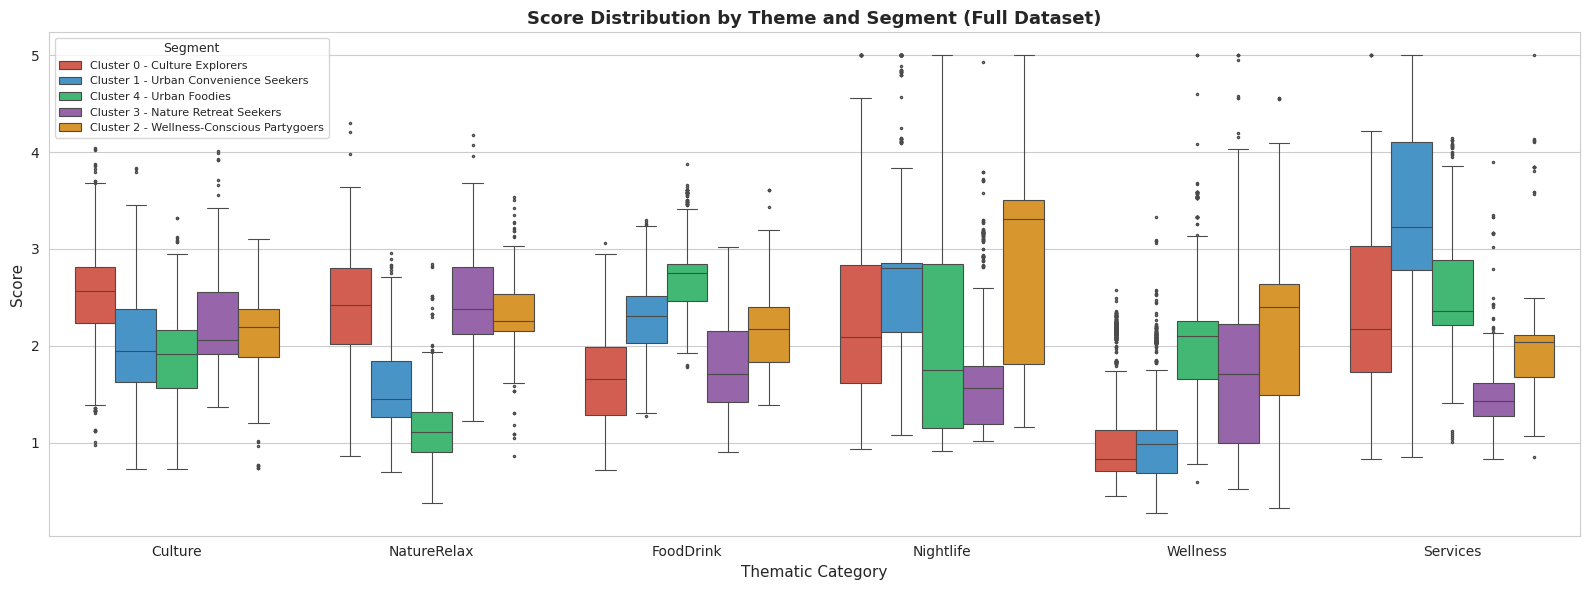

In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 18: SCORE DISTRIBUTION BY SEGMENT (FULL DATA)
# ═══════════════════════════════════════════════════════════════

box_df = engagement_df.copy()
box_df['Cluster'] = clusters
box_df['Segment'] = box_df['Cluster'].map(cluster_names)

melted = box_df.melt(
    id_vars='Segment',
    value_vars=eng_features,
    var_name='Theme',
    value_name='Score'
)

melted['Theme'] = melted['Theme'].str.replace('_Score', '')

fig, ax = plt.subplots(figsize=(16,6))

sns.boxplot(
    data=melted,
    x='Theme',
    y='Score',
    hue='Segment',
    palette=PALETTE,
    linewidth=0.8,
    fliersize=1.5,
    ax=ax
)

ax.set_title('Score Distribution by Theme and Segment (Full Dataset)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Thematic Category', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.legend(title='Segment', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig('profile_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 19: BUSINESS SEGMENT STRATEGY (FULL DATA)
# ═══════════════════════════════════════════════════════════════

total_users = len(cluster_series)

strategy = pd.DataFrame([
    {
        'Segment': 'Culture Explorers',
        'Size': f"{sizes[0]:,} ({sizes[0]/total_users*100:.1f}%)",
        'Top Interests': 'Museums, Churches, Theatres, Historic Sites, Art Galleries',
        'Travel Package': 'Grand European Heritage Tour: 10 days in Rome, Paris, Prague, Vienna',
        'Positioning': 'Immerse yourself in Europe\'s rich cultural tapestry — art, history, and architecture',
        'Target Demo': 'Ages 40–65, educated, moderate-to-high income, families and couples',
        'Channels': 'Travel magazines, Pinterest, email newsletters, museum partnerships'
    },
    {
        'Segment': 'Urban Convenience Seekers',
        'Size': f"{sizes[1]:,} ({sizes[1]/total_users*100:.1f}%)",
        'Top Interests': 'Local Services such as Malls, Restaurants, Hotels, Transportation, Shopping',
        'Travel Package': 'European City Essentials — 7 days: London, Amsterdam, Brussels',
        'Positioning': 'Hassle-free urban exploration — seamless services and city comforts at every turn',
        'Target Demo': 'Ages 25–50, business travelers, families, efficiency-focused',
        'Channels': 'Google Ads, TripAdvisor, Expedia, loyalty programs, airport advertising'
    },
    {
        'Segment': 'Nature Retreat Seekers',
        'Size': f"{sizes[3]:,} ({sizes[3]/total_users*100:.1f}%)",
        'Top Interests': 'Parks, Beaches, Gardens, Hiking Trails, Lakes, Mountains, ViewPoints',
        'Travel Package': 'European Nature Escape: 10 days across the Scottish Highlands, Swiss Alps, Norwegian Fjords',
        'Positioning': 'Disconnect and breathe: Europe\'s most serene landscapes away from the crowds',
        'Target Demo': 'Ages 30–60, nature lovers, introverts, couples and solo travelers',
        'Channels': 'Outdoor magazines, hiking blogs, nature photography Instagram, REI partnerships'
    },
    {
        'Segment': 'Urban Foodies',
        'Size': f"{sizes[4]:,} ({sizes[4]/total_users*100:.1f}%)",
        'Top Interests': 'Restaurants, Cafes, Bakeries, Food Markets, Wine Bars, Cooking Classes',
        'Travel Package': 'European Culinary Tour: 9 days in San Sebastián, Lyon, Bologna, Copenhagen',
        'Positioning': 'Taste Europe\'s soul: Michelin stars, street food, and everything in between',
        'Target Demo': 'Ages 28–55, food-motivated, moderate-to-high income, couples and groups',
        'Channels': 'Food blogs, Instagram, YouTube food channels, culinary influencers'
    },
    {
        'Segment': 'Wellness-Conscious Partygoers',
        'Size': f"{sizes[2]:,} ({sizes[2]/total_users*100:.1f}%)",
        'Top Interests': 'Dance Clubs, Bars, Spas, Gyms, Beaches, Resorts',
        'Travel Package': 'European Nightlife & Rejuvenation: 8 days in Barcelona, Berlin, Mykonos',
        'Positioning': 'Dance till dawn, recover by day: Europe\'s hottest scenes with spa-level self-care',
        'Target Demo': 'Ages 21–40, social, health-conscious, high-energy, experience-seeking',
        'Channels': 'Instagram, TikTok, nightlife apps, wellness influencers, festival partnerships'
    }

])

strategy.set_index('Segment', inplace=True)
display(strategy)

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print("✓ Train-test validation confirms stable clustering")
print("✓ Final model fitted on complete dataset")
print("✓ Business segments ready for deployment")

,Size,Top Interests,Travel Package,Positioning,Target Demo,Channels
Segment,,,,,,
Culture Explorers,"1,922 (35.2%)","Museums, Churches, Theatres, Historic Sites, A...","Grand European Heritage Tour: 10 days in Rome,...",Immerse yourself in Europe's rich cultural tap...,"Ages 40–65, educated, moderate-to-high income,...","Travel magazines, Pinterest, email newsletters..."
Urban Convenience Seekers,"1,786 (32.7%)","Local Services such as Malls, Restaurants, Hot...","European City Essentials — 7 days: London, Ams...",Hassle-free urban exploration — seamless servi...,"Ages 25–50, business travelers, families, effi...","Google Ads, TripAdvisor, Expedia, loyalty prog..."
Nature Retreat Seekers,869 (15.9%),"Parks, Beaches, Gardens, Hiking Trails, Lakes,...",European Nature Escape: 10 days across the Sco...,Disconnect and breathe: Europe's most serene l...,"Ages 30–60, nature lovers, introverts, couples...","Outdoor magazines, hiking blogs, nature photog..."
Urban Foodies,615 (11.3%),"Restaurants, Cafes, Bakeries, Food Markets, Wi...",European Culinary Tour: 9 days in San Sebastiá...,"Taste Europe's soul: Michelin stars, street fo...","Ages 28–55, food-motivated, moderate-to-high i...","Food blogs, Instagram, YouTube food channels, ..."
Wellness-Conscious Partygoers,263 (4.8%),"Dance Clubs, Bars, Spas, Gyms, Beaches, Resorts",European Nightlife & Rejuvenation: 8 days in B...,"Dance till dawn, recover by day: Europe's hott...","Ages 21–40, social, health-conscious, high-ene...","Instagram, TikTok, nightlife apps, wellness in..."



ANALYSIS COMPLETE
✓ Train-test validation confirms stable clustering
✓ Final model fitted on complete dataset
✓ Business segments ready for deployment
